In [61]:
# importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [62]:
# lectura de datos
d = pd.read_csv("/content/icfes_data.csv", sep='\t')

/tmp/ipykernel_121972/340613318.py:2: DtypeWarning: Columns (77,80,81,82,83) have mixed types. Specify dtype option on import or set low_memory=False.
  d = pd.read_csv("/content/icfes_data.csv", sep='\t')


In [63]:
d

,ESTU_CONSECUTIVO,ESTU_TIPODOCUMENTO,ESTU_NACIONALIDAD,ESTU_GENERO,ESTU_FECHANACIMIENTO,PERIODO,ESTU_ESTUDIANTE,ESTU_PAIS_RESIDE,ESTU_TIENEETNIA,ESTU_DEPTO_RESIDE,...,PUNT_GLOBAL,PERCENTIL_GLOBAL,ESTU_INSE_INDIVIDUAL,ESTU_NSE_INDIVIDUAL,ESTU_NSE_ESTABLECIMIENTO,ESTU_ESTADOINVESTIGACION,ESTU_GENERACION-E,ESTU_ETNIA,ESTU_PILOPAGA,ESTU_LIMITA_MOTRIZ
0,SB11202040001656,TI,COLOMBIA,M,03/07/2003,20204,ESTUDIANTE,COLOMBIA,No,CALDAS,...,261,61.0,61.340840,3.0,3.0,PUBLICAR,NO,NaN,NaN,NaN
1,SB11202040001763,TI,COLOMBIA,F,16/06/2003,20204,ESTUDIANTE,COLOMBIA,No,BOGOTÁ,...,306,87.0,71.825844,4.0,4.0,PUBLICAR,NO,NaN,NaN,NaN
2,SB11202040001490,TI,COLOMBIA,F,11/09/2003,20204,ESTUDIANTE,COLOMBIA,No,BOGOTÁ,...,321,92.0,57.286312,3.0,3.0,PUBLICAR,NO,NaN,NaN,NaN
3,SB11202040096445,TI,COLOMBIA,M,05/03/2004,20204,ESTUDIANTE,COLOMBIA,No,BOGOTÁ,...,338,96.0,67.476602,4.0,4.0,PUBLICAR,NO,NaN,NaN,NaN
4,SB11202040048154,TI,COLOMBIA,M,30/08/2003,20204,ESTUDIANTE,COLOMBIA,No,TOLIMA,...,225,35.0,43.877158,2.0,2.0,PUBLICAR,GENERACION E - GRATUIDAD,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1650058,SB11202010002849,TI,ITALIA,F,24/08/0003,20201,ESTUDIANTE,ITALIA,No,VALLE,...,303,54.0,NaN,NaN,NaN,PUBLICAR,NO,NaN,NaN,NaN
1650059,SB11202010004430,TI,PAÍSES BAJOS - HOLANDA,F,21/05/2002,20201,ESTUDIANTE,PAÍSES BAJOS - HOLANDA,No,VALLE,...,366,91.0,NaN,NaN,NaN,PUBLICAR,NO,NaN,NaN,NaN
1650060,SB11202010008503,TI,VENEZUELA,F,07/12/2001,20201,ESTUDIANTE,VENEZUELA,No,BOGOTÁ,...,337,76.0,NaN,NaN,NaN,PUBLICAR,NO,NaN,NaN,NaN
1650061,SB11202010072919,TI,VENEZUELA,F,25/04/2003,20201,ESTUDIANTE,VENEZUELA,No,NORTE SANTANDER,...,253,28.0,NaN,NaN,NaN,PUBLICAR,GENERACION E - GRATUIDAD,NaN,NaN,NaN


In [64]:
# seleccion de las columnas utilies para la elaboracion de nuestro modelo
dn = [
    'PERCENTIL_GLOBAL',
    'PUNT_GLOBAL',
    'PUNT_C_NATURALES',
    'PUNT_LECTURA_CRITICA',
    'ESTU_GENERO',
    'ESTU_HORASSEMANATRABAJA',
    'FAMI_ESTRATOVIVIENDA',
    'FAMI_TIENEINTERNET',
    'FAMI_TIENECOMPUTADOR',
    'FAMI_EDUCACIONMADRE',
    'FAMI_EDUCACIONPADRE',
    'FAMI_SITUACIONECONOMICA',
    'FAMI_NUMLIBROS',
    'ESTU_DEDICACIONLECTURADIARIA',
    'COLE_BILINGUE',
    "COLE_CARACTER",
    'COLE_AREA_UBICACION',
    'COLE_NATURALEZA',
]

In [65]:
# creamos el nuevo data frame con las columnas seleccionadas
df = d[dn]
df


,PERCENTIL_GLOBAL,PUNT_GLOBAL,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,ESTU_GENERO,ESTU_HORASSEMANATRABAJA,FAMI_ESTRATOVIVIENDA,FAMI_TIENEINTERNET,FAMI_TIENECOMPUTADOR,FAMI_EDUCACIONMADRE,FAMI_EDUCACIONPADRE,FAMI_SITUACIONECONOMICA,FAMI_NUMLIBROS,ESTU_DEDICACIONLECTURADIARIA,COLE_BILINGUE,COLE_CARACTER,COLE_AREA_UBICACION,COLE_NATURALEZA
0,61.0,261,50,53,M,0,Estrato 5,Si,Si,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,Peor,0 A 10 LIBROS,30 minutos o menos,N,ACADÉMICO,URBANO,NO OFICIAL
1,87.0,306,63,62,F,Entre 11 y 20 horas,Estrato 3,Si,Si,Educación profesional completa,Postgrado,Igual,MÁS DE 100 LIBROS,30 minutos o menos,N,ACADÉMICO,URBANO,NO OFICIAL
2,92.0,321,63,65,F,0,Estrato 1,Si,No,Técnica o tecnológica incompleta,Técnica o tecnológica completa,Peor,26 A 100 LIBROS,Entre 30 y 60 minutos,N,ACADÉMICO,URBANO,OFICIAL
3,96.0,338,75,64,M,0,Estrato 3,Si,Si,Educación profesional completa,Postgrado,Igual,26 A 100 LIBROS,30 minutos o menos,N,ACADÉMICO,URBANO,NO OFICIAL
4,35.0,225,45,56,M,Entre 11 y 20 horas,Estrato 1,Si,No,Secundaria (Bachillerato) incompleta,Primaria completa,Igual,0 A 10 LIBROS,30 minutos o menos,N,ACADÉMICO,URBANO,OFICIAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1650058,54.0,303,64,64,F,0,Estrato 4,Si,Si,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,Igual,26 A 100 LIBROS,Entre 30 y 60 minutos,N,ACADÉMICO,URBANO,NO OFICIAL
1650059,91.0,366,72,70,F,0,Estrato 5,Si,Si,No Aplica,No Aplica,Igual,MÁS DE 100 LIBROS,Entre 30 y 60 minutos,NaN,ACADÉMICO,URBANO,NO OFICIAL
1650060,76.0,337,65,71,F,NaN,Estrato 5,Si,NaN,Educación profesional completa,Primaria incompleta,NaN,26 A 100 LIBROS,Más de 2 horas,S,ACADÉMICO,URBANO,NO OFICIAL
1650061,28.0,253,52,59,F,Más de 30 horas,Estrato 2,No,No,Educación profesional completa,Secundaria (Bachillerato) incompleta,Peor,0 A 10 LIBROS,Entre 1 y 2 horas,N,ACADÉMICO,URBANO,NO OFICIAL


In [66]:
# limpiamos el puntaje global para garantizar que sea 100% numerico
df['PUNT_GLOBAL'] = pd.to_numeric(df['PUNT_GLOBAL'], errors='coerce')

# Eliminamos filas que tengan el puntaje global vacío
df = df.dropna(subset=['PUNT_GLOBAL']).copy()


/tmp/ipykernel_121972/3214939879.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['PUNT_GLOBAL'] = pd.to_numeric(df['PUNT_GLOBAL'], errors='coerce')


In [67]:
# definimos el umbral para pasar a medicina
umbral_real_medicina = 400

In [68]:
# creamos la variable dummy que determina si el estudiante pasa o no a medicina con base al umbral de 400 pts (variable objetivo)
df['PASO_MEDICINA'] = np.where(df['PUNT_GLOBAL'] >= umbral_real_medicina, 1, 0)

In [69]:
df

,PERCENTIL_GLOBAL,PUNT_GLOBAL,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,ESTU_GENERO,ESTU_HORASSEMANATRABAJA,FAMI_ESTRATOVIVIENDA,FAMI_TIENEINTERNET,FAMI_TIENECOMPUTADOR,FAMI_EDUCACIONMADRE,FAMI_EDUCACIONPADRE,FAMI_SITUACIONECONOMICA,FAMI_NUMLIBROS,ESTU_DEDICACIONLECTURADIARIA,COLE_BILINGUE,COLE_CARACTER,COLE_AREA_UBICACION,COLE_NATURALEZA,PASO_MEDICINA
0,61.0,261,50,53,M,0,Estrato 5,Si,Si,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,Peor,0 A 10 LIBROS,30 minutos o menos,N,ACADÉMICO,URBANO,NO OFICIAL,0
1,87.0,306,63,62,F,Entre 11 y 20 horas,Estrato 3,Si,Si,Educación profesional completa,Postgrado,Igual,MÁS DE 100 LIBROS,30 minutos o menos,N,ACADÉMICO,URBANO,NO OFICIAL,0
2,92.0,321,63,65,F,0,Estrato 1,Si,No,Técnica o tecnológica incompleta,Técnica o tecnológica completa,Peor,26 A 100 LIBROS,Entre 30 y 60 minutos,N,ACADÉMICO,URBANO,OFICIAL,0
3,96.0,338,75,64,M,0,Estrato 3,Si,Si,Educación profesional completa,Postgrado,Igual,26 A 100 LIBROS,30 minutos o menos,N,ACADÉMICO,URBANO,NO OFICIAL,0
4,35.0,225,45,56,M,Entre 11 y 20 horas,Estrato 1,Si,No,Secundaria (Bachillerato) incompleta,Primaria completa,Igual,0 A 10 LIBROS,30 minutos o menos,N,ACADÉMICO,URBANO,OFICIAL,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1650058,54.0,303,64,64,F,0,Estrato 4,Si,Si,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,Igual,26 A 100 LIBROS,Entre 30 y 60 minutos,N,ACADÉMICO,URBANO,NO OFICIAL,0
1650059,91.0,366,72,70,F,0,Estrato 5,Si,Si,No Aplica,No Aplica,Igual,MÁS DE 100 LIBROS,Entre 30 y 60 minutos,NaN,ACADÉMICO,URBANO,NO OFICIAL,0
1650060,76.0,337,65,71,F,NaN,Estrato 5,Si,NaN,Educación profesional completa,Primaria incompleta,NaN,26 A 100 LIBROS,Más de 2 horas,S,ACADÉMICO,URBANO,NO OFICIAL,0
1650061,28.0,253,52,59,F,Más de 30 horas,Estrato 2,No,No,Educación profesional completa,Secundaria (Bachillerato) incompleta,Peor,0 A 10 LIBROS,Entre 1 y 2 horas,N,ACADÉMICO,URBANO,NO OFICIAL,0


In [70]:
#ANALISIS EXPLORATORIO
# a) analisis de estructura y calidad de datos

# dimensiones del dataset
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")

# tipos de datos
print(df.info())

# conteo de valores nulos en las variables
variables_clave = [
   'PERCENTIL_GLOBAL',
    'PUNT_GLOBAL',
    'PUNT_C_NATURALES',
    'PUNT_LECTURA_CRITICA',
    'ESTU_GENERO',
    'ESTU_HORASSEMANATRABAJA',
    'FAMI_ESTRATOVIVIENDA',
    'FAMI_TIENEINTERNET',
    'FAMI_TIENECOMPUTADOR',
    'FAMI_EDUCACIONMADRE',
    'FAMI_EDUCACIONPADRE',
    'FAMI_SITUACIONECONOMICA',
    'FAMI_NUMLIBROS',
    'ESTU_DEDICACIONLECTURADIARIA',
    'COLE_BILINGUE',
    "COLE_CARACTER",
    'COLE_AREA_UBICACION',
    'COLE_NATURALEZA',
]
print("\n• Valores faltantes (nulos) por variable clave elegida:")
print(df[variables_clave].isnull().sum())

El dataset tiene 1650063 filas y 19 columnas.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1650063 entries, 0 to 1650062
Data columns (total 19 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   PERCENTIL_GLOBAL              1650008 non-null  float64
 1   PUNT_GLOBAL                   1650063 non-null  int64  
 2   PUNT_C_NATURALES              1650063 non-null  int64  
 3   PUNT_LECTURA_CRITICA          1650063 non-null  int64  
 4   ESTU_GENERO                   1649948 non-null  object 
 5   ESTU_HORASSEMANATRABAJA       1593953 non-null  object 
 6   FAMI_ESTRATOVIVIENDA          1555890 non-null  object 
 7   FAMI_TIENEINTERNET            1566293 non-null  object 
 8   FAMI_TIENECOMPUTADOR          1590979 non-null  object 
 9   FAMI_EDUCACIONMADRE           1567528 non-null  object 
 10  FAMI_EDUCACIONPADRE           1567648 non-null  object 
 11  FAMI_SITUACIONECONOMICA       1593843 non-n

/tmp/ipykernel_121972/4042894815.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='PASO_MEDICINA', data=df, palette='viridis')


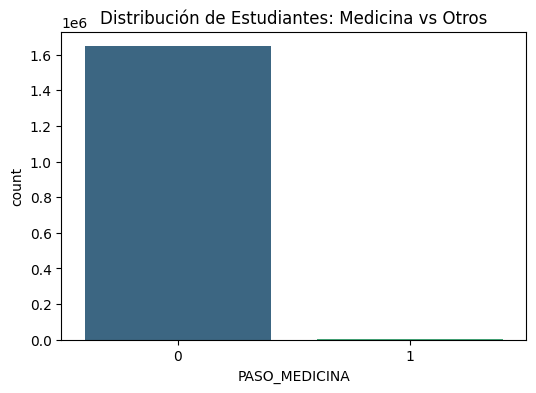

PASO_MEDICINA
0    99.797765
1     0.202235
Name: proportion, dtype: float64


In [71]:

# b) analisis de la variable independiente
plt.figure(figsize=(6,4))
sns.countplot(x='PASO_MEDICINA', data=df, palette='viridis')
plt.title('Distribución de Estudiantes: Medicina vs Otros')
plt.show()

print(df['PASO_MEDICINA'].value_counts(normalize=True) * 100)


--- PASO 2: Análisis Univariado ---

• Resumen estadístico del Puntaje Global a nivel nacional:
count    1.650063e+06
mean     2.497869e+02
std      5.112048e+01
min      0.000000e+00
25%      2.110000e+02
50%      2.460000e+02
75%      2.850000e+02
max      5.000000e+02
Name: PUNT_GLOBAL, dtype: float64

• Diagnóstico de la Variable Dummy (PASO_MEDICINA):
  - No Pasa (<400): 1,646,726 estudiantes (99.798%)
  - Pasa a Medicina (>=400): 3,337 estudiantes (0.202%)


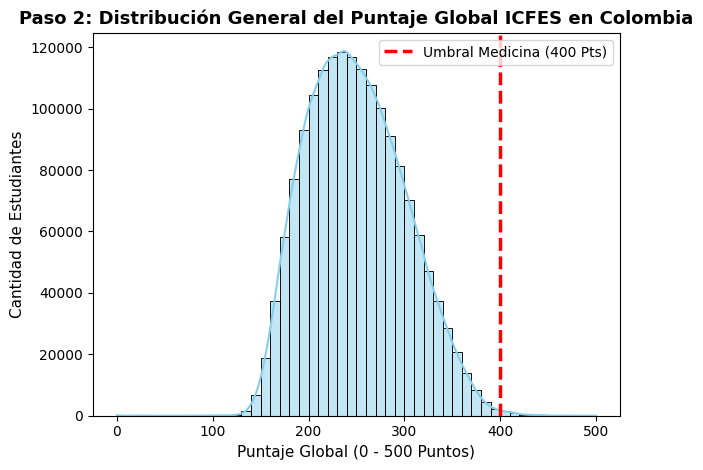

In [72]:
# c) analisis univariado
print("\n--- PASO 2: Análisis Univariado ---")
#  Distribución estadística de la variable numérica principal
print("\n• Resumen estadístico del Puntaje Global a nivel nacional:")
print(df['PUNT_GLOBAL'].describe())

# Diagnóstico de Desbalanceo de Clases (Variable Objetivo)
print("\n• Diagnóstico de la Variable Dummy (PASO_MEDICINA):")
conteo_clases = df['PASO_MEDICINA'].value_counts()
porcentaje_clases = df['PASO_MEDICINA'].value_counts(normalize=True) * 100
for cat in conteo_clases.index:
    estado = "Pasa a Medicina (>=400)" if cat == 1 else "No Pasa (<400)"
    print(f"  - {estado}: {conteo_clases[cat]:,} estudiantes ({porcentaje_clases[cat]:.3f}%)")

# Gráfica Univariada: Distribución del Puntaje Global del examen
plt.figure()
sns.histplot(df['PUNT_GLOBAL'], bins=50, kde=True, color='skyblue', edgecolor='black')
plt.axvline(x=400, color='red', linestyle='--', linewidth=2.5, label='Umbral Medicina (400 Pts)')
plt.title('Paso 2: Distribución General del Puntaje Global ICFES en Colombia', fontsize=13, fontweight='bold')
plt.xlabel('Puntaje Global (0 - 500 Puntos)', fontsize=11)
plt.ylabel('Cantidad de Estudiantes', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()


- Análisis Bivariado y Multivariado
Tasa de éxito para Medicina (>=400 puntos) según el Estrato de Vivienda:
FAMI_ESTRATOVIVIENDA
Estrato 1       0.05 %
Estrato 2      0.099 %
Estrato 3      0.229 %
Estrato 4      0.987 %
Estrato 5       1.78 %
Estrato 6      2.134 %
Sin Estrato    0.042 %
Name: PASO_MEDICINA, dtype: object


/tmp/ipykernel_121972/2216956582.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='FAMI_ESTRATOVIVIENDA', y='PUNT_GLOBAL', data=df, order=orden_estrato, palette="YlGnBu")


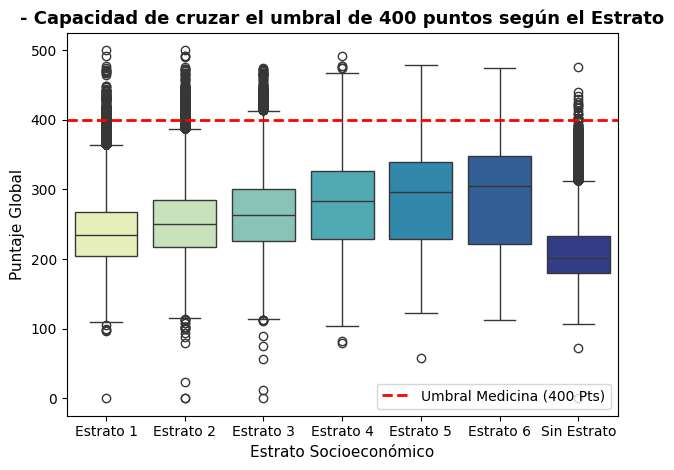

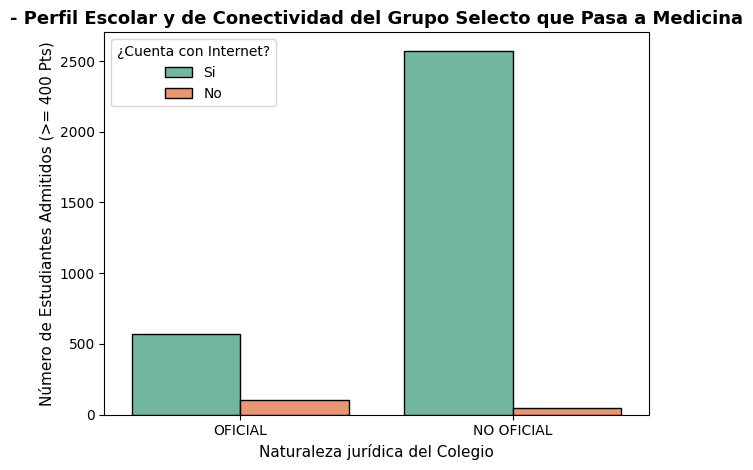

In [73]:
# d) analisis bivariado y multivariado
print("- Análisis Bivariado y Multivariado")

# 3.1 Relación Estrato Social vs Probabilidad de Admisión
print("Tasa de éxito para Medicina (>=400 puntos) según el Estrato de Vivienda:")
tabla_estrato = df.groupby('FAMI_ESTRATOVIVIENDA')['PASO_MEDICINA'].mean() * 100
print(tabla_estrato.round(3).astype(str) + " %")

# Gráfica Bivariada A: Caja (Estrato vs Puntaje)
plt.figure()
orden_estrato = sorted(df['FAMI_ESTRATOVIVIENDA'].dropna().unique())
sns.boxplot(x='FAMI_ESTRATOVIVIENDA', y='PUNT_GLOBAL', data=df, order=orden_estrato, palette="YlGnBu")
plt.axhline(y=400, color='red', linestyle='--', linewidth=2, label='Umbral Medicina (400 Pts)')
plt.title('- Capacidad de cruzar el umbral de 400 puntos según el Estrato', fontsize=13, fontweight='bold')
plt.xlabel('Estrato Socioeconómico', fontsize=11)
plt.ylabel('Puntaje Global', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

# Gráfica Bivariada B: Barras cruzadas (Colegio e Internet vs Admisión)
plt.figure()
# Filtramos temporalmente la data para visualizar mejor la proporción de los que sí pasan
df_admitidos = df[df['PASO_MEDICINA'] == 1]
if len(df_admitidos) > 0:
    sns.countplot(x='COLE_NATURALEZA', hue='FAMI_TIENEINTERNET', data=df_admitidos, palette="Set2", edgecolor='black')
    plt.title('- Perfil Escolar y de Conectividad del Grupo Selecto que Pasa a Medicina', fontsize=13, fontweight='bold')
    plt.xlabel('Naturaleza jurídica del Colegio', fontsize=11)
    plt.ylabel('Número de Estudiantes Admitidos (>= 400 Pts)', fontsize=11)
    plt.legend(title='¿Cuenta con Internet?')
    plt.tight_layout()
    plt.show()
else:
    print("Nota: No se detectaron estudiantes con puntajes mayores o iguales a 400 en la muestra actual.")

In [74]:
df

,PERCENTIL_GLOBAL,PUNT_GLOBAL,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,ESTU_GENERO,ESTU_HORASSEMANATRABAJA,FAMI_ESTRATOVIVIENDA,FAMI_TIENEINTERNET,FAMI_TIENECOMPUTADOR,FAMI_EDUCACIONMADRE,FAMI_EDUCACIONPADRE,FAMI_SITUACIONECONOMICA,FAMI_NUMLIBROS,ESTU_DEDICACIONLECTURADIARIA,COLE_BILINGUE,COLE_CARACTER,COLE_AREA_UBICACION,COLE_NATURALEZA,PASO_MEDICINA
0,61.0,261,50,53,M,0,Estrato 5,Si,Si,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,Peor,0 A 10 LIBROS,30 minutos o menos,N,ACADÉMICO,URBANO,NO OFICIAL,0
1,87.0,306,63,62,F,Entre 11 y 20 horas,Estrato 3,Si,Si,Educación profesional completa,Postgrado,Igual,MÁS DE 100 LIBROS,30 minutos o menos,N,ACADÉMICO,URBANO,NO OFICIAL,0
2,92.0,321,63,65,F,0,Estrato 1,Si,No,Técnica o tecnológica incompleta,Técnica o tecnológica completa,Peor,26 A 100 LIBROS,Entre 30 y 60 minutos,N,ACADÉMICO,URBANO,OFICIAL,0
3,96.0,338,75,64,M,0,Estrato 3,Si,Si,Educación profesional completa,Postgrado,Igual,26 A 100 LIBROS,30 minutos o menos,N,ACADÉMICO,URBANO,NO OFICIAL,0
4,35.0,225,45,56,M,Entre 11 y 20 horas,Estrato 1,Si,No,Secundaria (Bachillerato) incompleta,Primaria completa,Igual,0 A 10 LIBROS,30 minutos o menos,N,ACADÉMICO,URBANO,OFICIAL,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1650058,54.0,303,64,64,F,0,Estrato 4,Si,Si,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,Igual,26 A 100 LIBROS,Entre 30 y 60 minutos,N,ACADÉMICO,URBANO,NO OFICIAL,0
1650059,91.0,366,72,70,F,0,Estrato 5,Si,Si,No Aplica,No Aplica,Igual,MÁS DE 100 LIBROS,Entre 30 y 60 minutos,NaN,ACADÉMICO,URBANO,NO OFICIAL,0
1650060,76.0,337,65,71,F,NaN,Estrato 5,Si,NaN,Educación profesional completa,Primaria incompleta,NaN,26 A 100 LIBROS,Más de 2 horas,S,ACADÉMICO,URBANO,NO OFICIAL,0
1650061,28.0,253,52,59,F,Más de 30 horas,Estrato 2,No,No,Educación profesional completa,Secundaria (Bachillerato) incompleta,Peor,0 A 10 LIBROS,Entre 1 y 2 horas,N,ACADÉMICO,URBANO,NO OFICIAL,0


In [75]:
# PREPROCESAMIENTO DE DATOS

In [76]:
# mapeos
# mapeos para columnas binarias

df['ESTU_GENERO'] = df['ESTU_GENERO'].map({'F': 0, 'M': 1})
df['FAMI_TIENEINTERNET'] = df['FAMI_TIENEINTERNET'].map({'Si': 1, 'No': 0})
df['FAMI_TIENECOMPUTADOR'] = df['FAMI_TIENECOMPUTADOR'].map({'Si': 1, 'No': 0})
df['COLE_BILINGUE'] = df['COLE_BILINGUE'].map({'N': 0, 'S': 1})
df['COLE_AREA_UBICACION'] = df['COLE_AREA_UBICACION'].map({'RURAL': 0, 'URBANO': 1})
df['COLE_NATURALEZA'] = df['COLE_NATURALEZA'].map({'OFICIAL': 0, 'NON OFICIAL': 1})

In [77]:
# llenamos nulos
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())
print("Nulos eliminados.")

Nulos eliminados.


In [78]:
# mapeo para variables estrato y situcion economica de las familias
# Estrato
est_map = {'Estrato 1': 1, 'Estrato 2': 2, 'Estrato 3': 3, 'Estrato 4': 4, 'Estrato 5': 5, 'Estrato 6': 6, 'Sin Estrato': 0}
df['FAMI_ESTRATOVIVIENDA'] = df['FAMI_ESTRATOVIVIENDA'].map(est_map)

# Situación económica
sit_map = {'Mucho peor': 0, 'Peor': 1, 'Igual': 2, 'Mejor': 3, 'Mucho mejor': 4}
df['FAMI_SITUACIONECONOMICA'] = df['FAMI_SITUACIONECONOMICA'].map(sit_map)

In [79]:
# mapeo para variables de habitos
# Libros
lib_map = {'0 A 10 LIBROS': 0, '11 A 25 LIBROS': 1, '26 A 100 LIBROS': 2, 'MÁS DE 100 LIBROS': 3}
df['FAMI_NUMLIBROS'] = df['FAMI_NUMLIBROS'].map(lib_map)

# Trabajo
tra_map = {'0': 0, 'Menos de 10 horas': 1, 'Entre 11 y 20 horas': 2, 'Entre 21 y 30 horas': 3, 'Más de 30 horas': 4}
df['ESTU_HORASSEMANATRABAJA'] = df['ESTU_HORASSEMANATRABAJA'].map(tra_map)

# Lectura
lec_map = {'No leo por entretenimiento': 0, '30 minutos o menos': 1, 'Entre 30 y 60 minutos': 2, 'Entre 1 y 2 horas': 3, 'Más de 2 horas': 4}
df['ESTU_DEDICACIONLECTURADIARIA'] = df['ESTU_DEDICACIONLECTURADIARIA'].map(lec_map)


In [80]:
# mapeo variables educacion de los padres
# Aseguramos que df sea independiente
df = df.copy()

# 1. Definimos el mapa de jerarquía
edu_map = {
    'No sabe': 0, 'No aplicó': 0, 'Ninguno': 0, 'No Aplica': 0,
    'Primaria incompleta': 1, 'Primaria completa': 2,
    'Secundaria (Bachillerato) incompleta': 3, 'Secundaria (Bachillerato) completa': 4,
    'Técnica o tecnológica incompleta': 5, 'Técnica o tecnológica completa': 6,
    'Educación profesional incompleta': 7, 'Educación profesional completa': 8,
    'Postgrado': 9
}

# procesar educacion madre
if df['FAMI_EDUCACIONMADRE'].dtype == 'object': # Solo actúa si todavía es texto
    # Llenar nulos con moda
    moda_m = df['FAMI_EDUCACIONMADRE'].mode().iloc[0]
    df['FAMI_EDUCACIONMADRE'] = df['FAMI_EDUCACIONMADRE'].fillna(moda_m)
    # Convertir a números
    df['FAMI_EDUCACIONMADRE'] = df['FAMI_EDUCACIONMADRE'].map(edu_map)

# procesar educacion padre
if df['FAMI_EDUCACIONPADRE'].dtype == 'object': # Solo actúa si todavía es texto
    # Llenar nulos con moda
    moda_p = df['FAMI_EDUCACIONPADRE'].mode().iloc[0]
    df['FAMI_EDUCACIONPADRE'] = df['FAMI_EDUCACIONPADRE'].fillna(moda_p)
    # Convertir a números
    df['FAMI_EDUCACIONPADRE'] = df['FAMI_EDUCACIONPADRE'].map(edu_map)

In [81]:
# verificacion de valores nulos
variables_clave = [
   'PERCENTIL_GLOBAL',
    'PUNT_GLOBAL',
    'PUNT_C_NATURALES',
    'PUNT_LECTURA_CRITICA',
    'ESTU_GENERO',
    'ESTU_HORASSEMANATRABAJA',
    'FAMI_ESTRATOVIVIENDA',
    'FAMI_TIENEINTERNET',
    'FAMI_TIENECOMPUTADOR',
    'FAMI_EDUCACIONMADRE',
    'FAMI_EDUCACIONPADRE',
    'FAMI_SITUACIONECONOMICA',
    'FAMI_NUMLIBROS',
    'ESTU_DEDICACIONLECTURADIARIA',
    'COLE_BILINGUE',
    "COLE_CARACTER",
    'COLE_AREA_UBICACION',
    'COLE_NATURALEZA',
]
print("\n• Valores faltantes (nulos) por variable clave elegida:")
print(df[variables_clave].isnull().sum())


• Valores faltantes (nulos) por variable clave elegida:
PERCENTIL_GLOBAL                0
PUNT_GLOBAL                     0
PUNT_C_NATURALES                0
PUNT_LECTURA_CRITICA            0
ESTU_GENERO                     0
ESTU_HORASSEMANATRABAJA         0
FAMI_ESTRATOVIVIENDA            0
FAMI_TIENEINTERNET              0
FAMI_TIENECOMPUTADOR            0
FAMI_EDUCACIONMADRE             0
FAMI_EDUCACIONPADRE             0
FAMI_SITUACIONECONOMICA         0
FAMI_NUMLIBROS                  0
ESTU_DEDICACIONLECTURADIARIA    0
COLE_BILINGUE                   0
COLE_CARACTER                   0
COLE_AREA_UBICACION             0
COLE_NATURALEZA                 0
dtype: int64


In [82]:
df

,PERCENTIL_GLOBAL,PUNT_GLOBAL,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,ESTU_GENERO,ESTU_HORASSEMANATRABAJA,FAMI_ESTRATOVIVIENDA,FAMI_TIENEINTERNET,FAMI_TIENECOMPUTADOR,FAMI_EDUCACIONMADRE,FAMI_EDUCACIONPADRE,FAMI_SITUACIONECONOMICA,FAMI_NUMLIBROS,ESTU_DEDICACIONLECTURADIARIA,COLE_BILINGUE,COLE_CARACTER,COLE_AREA_UBICACION,COLE_NATURALEZA,PASO_MEDICINA
0,61.0,261,50,53,1.0,0,5,1.0,1.0,4,4,1,0,1,0.0,ACADÉMICO,1,0.0,0
1,87.0,306,63,62,0.0,2,3,1.0,1.0,8,9,2,3,1,0.0,ACADÉMICO,1,0.0,0
2,92.0,321,63,65,0.0,0,1,1.0,0.0,5,6,1,2,2,0.0,ACADÉMICO,1,0.0,0
3,96.0,338,75,64,1.0,0,3,1.0,1.0,8,9,2,2,1,0.0,ACADÉMICO,1,0.0,0
4,35.0,225,45,56,1.0,2,1,1.0,0.0,3,2,2,0,1,0.0,ACADÉMICO,1,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1650058,54.0,303,64,64,0.0,0,4,1.0,1.0,4,4,2,2,2,0.0,ACADÉMICO,1,0.0,0
1650059,91.0,366,72,70,0.0,0,5,1.0,1.0,0,0,2,3,2,0.0,ACADÉMICO,1,0.0,0
1650060,76.0,337,65,71,0.0,0,5,1.0,1.0,8,1,2,2,4,1.0,ACADÉMICO,1,0.0,0
1650061,28.0,253,52,59,0.0,4,2,0.0,0.0,8,3,1,0,3,0.0,ACADÉMICO,1,0.0,0
